# COMP262 - Group 5
# Phase 2: Machine Learning Sentiment Analysis

**Dataset:** Amazon Gift Cards Reviews (Gift_Cards_5.json)

**Phase 1 Summary:** Lexicon-based sentiment analysis was carried out using VADER and TextBlob on a sample of 1,000 reviews from the Gift Cards dataset. Both models classified reviews as Positive, Neutral, or Negative based on the cleaned review text. VADER and TextBlob results were evaluated using accuracy, precision, recall, F1, and confusion matrices.

**Phase 2 Objective:** Build two supervised machine learning models for sentiment analysis, fine-tune them, evaluate them against the Phase 1 lexicon baselines on the same data, enhance rating values using review text, and apply local LLM models for summarisation and automated response generation.


---
## Import Libraries

All required libraries are imported here. This includes libraries for data handling, visualisation, text preprocessing, machine learning, evaluation, and Hugging Face model inference.



In [1]:
# !pip install vaderSentiment textblob scikit-learn transformers torch pandas numpy matplotlib seaborn nltk

import warnings
warnings.filterwarnings('ignore')

import sys
print(sys.version)

# Data manipulation
import pandas as pd
import numpy as np
import os
import re

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Text representation
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine learning models
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

# Model selection and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Lexicon models from Phase 1
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Hugging Face
from transformers import pipeline as hf_pipeline

print("All libraries imported successfully.")


3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
All libraries imported successfully.


---
## Section 1 - Load Dataset

We load the same Gift_Cards_5.json dataset used in Phase 1. Each row is one Amazon product review. The key fields used in this phase are:

- reviewText: the raw written review
- overall: the numeric star rating (1 to 5)
- reviewerID: unique user identifier
- asin: unique product identifier


In [2]:
# Update this path to match your local environment
file_path = "Gift_Cards.json"

df = pd.read_json(file_path, lines=True)

print("Total Reviews:", len(df))
print("Average Rating:", round(df['overall'].mean(), 4))
print("Columns:", list(df.columns))
df.info()


Total Reviews: 147194
Average Rating: 4.672
Columns: ['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'image']
<class 'pandas.DataFrame'>
RangeIndex: 147194 entries, 0 to 147193
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         147194 non-null  int64 
 1   vote            6341 non-null    str   
 2   verified        147194 non-null  bool  
 3   reviewTime      147194 non-null  str   
 4   reviewerID      147194 non-null  str   
 5   asin            147194 non-null  str   
 6   style           42375 non-null   object
 7   reviewerName    147190 non-null  str   
 8   reviewText      147035 non-null  str   
 9   summary         147154 non-null  str   
 10  unixReviewTime  147194 non-null  int64 
 11  image           406 non-null     object
dtypes: bool(1), int64(2), object(2), str(7)
memory usage: 12.5+ MB


---
## Section 2 - Basic Information and Exploration (Full Dataset)

Before selecting our subset we take a quick look at the full dataset to understand the overall distribution of ratings, reviews per product, and reviews per user.


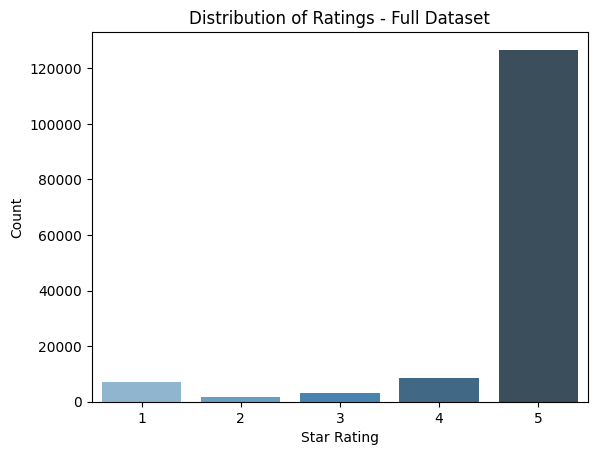

In [3]:
# Rating distribution across the full dataset
sns.countplot(x='overall', data=df, palette='Blues_d')
plt.title("Distribution of Ratings - Full Dataset")
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.show()


Reviews per product:
count    1548.000000
mean       95.086563
std       357.029918
min         1.000000
25%         3.000000
50%        14.000000
75%        54.000000
max      8174.000000
dtype: float64


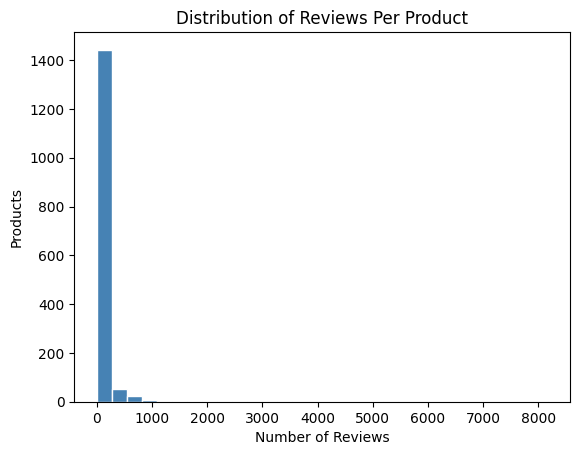

In [4]:
# Reviews per product
reviews_per_product = df.groupby('asin').size()
print("Reviews per product:")
print(reviews_per_product.describe())

plt.hist(reviews_per_product, bins=30, color='steelblue', edgecolor='white')
plt.title("Distribution of Reviews Per Product")
plt.xlabel("Number of Reviews")
plt.ylabel("Products")
plt.show()


Reviews per user:
count    128877.000000
mean          1.142128
std           0.616811
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          39.000000
dtype: float64


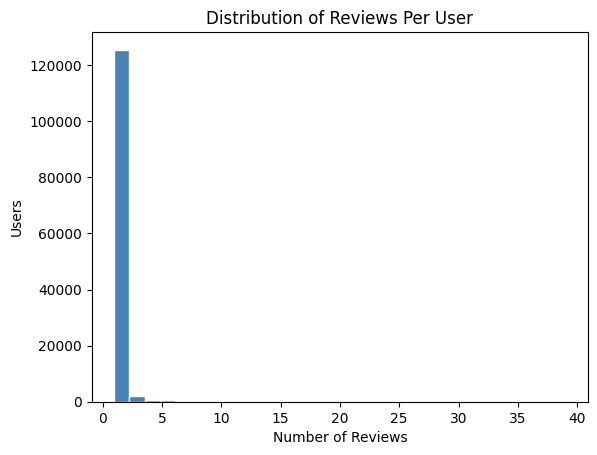

In [5]:
# Reviews per user
reviews_per_user = df.groupby('reviewerID').size()
print("Reviews per user:")
print(reviews_per_user.describe())

plt.hist(reviews_per_user, bins=30, color='steelblue', edgecolor='white')
plt.title("Distribution of Reviews Per User")
plt.xlabel("Number of Reviews")
plt.ylabel("Users")
plt.show()


count    147035.000000
mean         96.875574
std         130.983645
min           1.000000
25%          23.000000
50%          58.000000
75%         125.000000
max        5023.000000
Name: review_length, dtype: float64


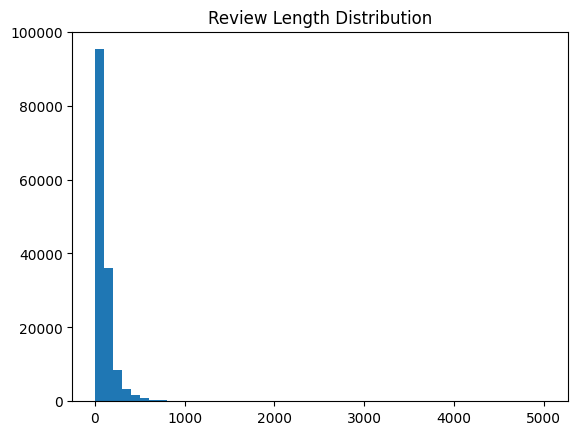

In [6]:
# Look at review length distribution
df['review_length'] = df['reviewText'].str.len()

print(df['review_length'].describe())

plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()



In [7]:
# Check for duplicate rows
print("Duplicate Rows:", df.select_dtypes(exclude=['object']).duplicated().sum())


Duplicate Rows: 34965


---
## Section 3 - Sentiment Labelling and Text Cleaning (Full Dataset)

We apply the sentiment label and text cleaning to the full dataset before selecting the subset. This ensures the subset we draw already has all fields populated.

The sentiment label is derived from the star rating:
- Rating 4 or 5 maps to Positive
- Rating 3 maps to Neutral
- Rating 1 or 2 maps to Negative


In [8]:
# Sentiment labelling from star rating
def label_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['overall'].apply(label_sentiment)
print("Sentiment distribution (full dataset):")
print(df['sentiment'].value_counts())


Sentiment distribution (full dataset):
sentiment
Positive    135389
Negative      8809
Neutral       2996
Name: count, dtype: int64


In [9]:
# Text cleaning

stop_words = set(stopwords.words('english')) - {'not', 'no'}
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                           # Step 1: lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)           # Step 2: remove non-alphabetic characters
    words = text.split()                               # Step 3: tokenise
    words = [w for w in words if w not in stop_words] # Step 4: remove stopwords
    words = [lemmatizer.lemmatize(w) for w in words]  # Step 5: lemmatise
    return " ".join(words)

df['cleaned_text'] = df['reviewText'].astype(str).apply(clean_text)

df[['reviewText', 'cleaned_text']].head(3)


,reviewText,cleaned_text
0,"Amazon,\nI am shopping for Amazon.com gift car...",amazon shopping amazoncom gift card christmas ...
1,"I got this gift card from a friend, and it was...",got gift card friend best site much choose gre...
2,aren't we going to save trees?! :) People who ...,arent going save tree people complaining paper...


---
## Section 4 - Subset Selection

### 11a - Select a minimum of 2,000 reviews

We draw a stratified random sample of 2,000 reviews so that the rating class distribution in the subset reflects the full dataset proportionally.



In [10]:
RANDOM_STATE = 42
n = 2000   # or 2500, or 2996 if you want to use the max possible balanced size

df_pos = df[df['sentiment'] == 'Positive'].sample(n, random_state=RANDOM_STATE)
df_neg = df[df['sentiment'] == 'Negative'].sample(n, random_state=RANDOM_STATE)
df_neu = df[df['sentiment'] == 'Neutral'].sample(n, random_state=RANDOM_STATE)

df_sample = pd.concat([df_pos, df_neg, df_neu]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Subset size:", len(df_sample))
print(df_sample['sentiment'].value_counts())

print("Subset size:", len(df_sample))
print("Rating distribution in subset:")
print(df_sample['overall'].value_counts().sort_index())
print()
print("Sentiment distribution in subset:")
print(df_sample['sentiment'].value_counts())


Subset size: 6000
sentiment
Positive    2000
Negative    2000
Neutral     2000
Name: count, dtype: int64
Subset size: 6000
Rating distribution in subset:
overall
1    1639
2     361
3    2000
4     130
5    1870
Name: count, dtype: int64

Sentiment distribution in subset:
sentiment
Positive    2000
Negative    2000
Neutral     2000
Name: count, dtype: int64


---
## Section 5 - Data Exploration on the Subset

### 11b - Carry out data exploration on the subset


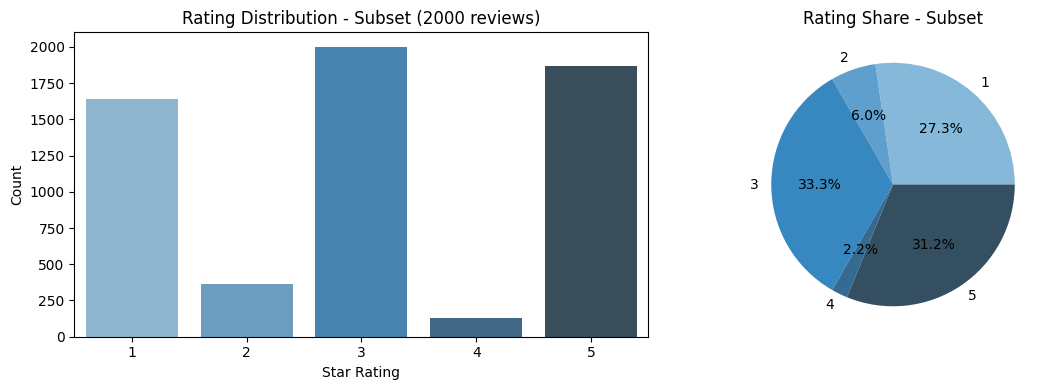

In [11]:
# Rating distribution in the subset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='overall', data=df_sample, palette='Blues_d', ax=axes[0])
axes[0].set_title("Rating Distribution - Subset (2000 reviews)")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Count")

df_sample['overall'].value_counts().sort_index().plot.pie(
    autopct='%1.1f%%', ax=axes[1],
    colors=sns.color_palette('Blues_d', 5)
)
axes[1].set_title("Rating Share - Subset")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


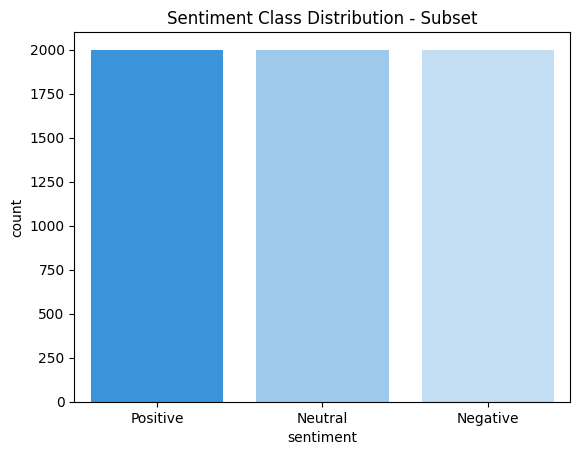

In [12]:
# Sentiment class distribution in the subset
sns.countplot(
    x='sentiment', data=df_sample,
    order=['Positive', 'Neutral', 'Negative'],
    palette=['#2196F3', '#90CAF9', '#BBDEFB']
)
plt.title("Sentiment Class Distribution - Subset")
plt.show()


In [13]:
# Missing values in the subset
print("Missing values per column in subset:")
print(df_sample.isnull().sum())


Missing values per column in subset:
overall              0
vote              5149
verified             0
reviewTime           0
reviewerID           0
asin                 0
style             4257
reviewerName         0
reviewText           1
summary              1
unixReviewTime       0
image             5948
review_length        1
sentiment            0
cleaned_text         0
dtype: int64


In [14]:
# Duplicate check in the subset
dups = df_sample.duplicated(subset=['reviewText']).sum()
print("Duplicate review texts in subset:", dups)


Duplicate review texts in subset: 226


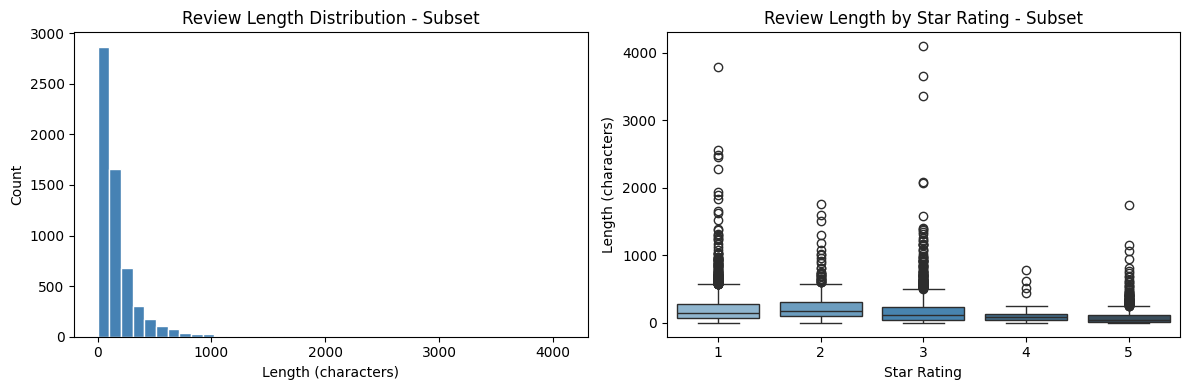

count    5999.000000
mean      164.908651
std       221.832222
min         1.000000
25%        40.500000
50%       109.000000
75%       203.000000
max      4099.000000
Name: review_length, dtype: float64


In [15]:
# Review length distribution in the subset
df_sample['review_length'] = df_sample['reviewText'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_sample['review_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title("Review Length Distribution - Subset")
axes[0].set_xlabel("Length (characters)")
axes[0].set_ylabel("Count")

sns.boxplot(x='overall', y='review_length', data=df_sample, palette='Blues_d', ax=axes[1])
axes[1].set_title("Review Length by Star Rating - Subset")
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("Length (characters)")

plt.tight_layout()
plt.show()

print(df_sample['review_length'].describe())


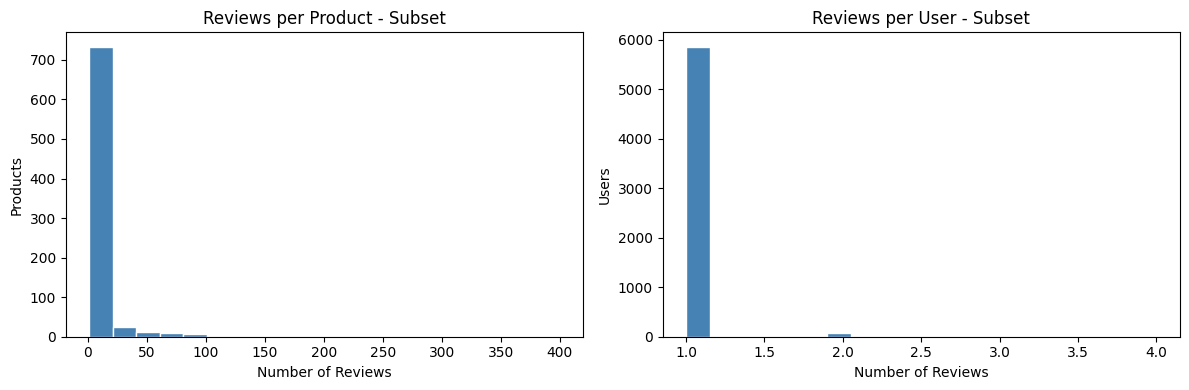

In [16]:
# Reviews per product and per user in the subset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rpp = df_sample.groupby('asin').size()
axes[0].hist(rpp, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title("Reviews per Product - Subset")
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("Products")

rpu = df_sample.groupby('reviewerID').size()
axes[1].hist(rpu, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title("Reviews per User - Subset")
axes[1].set_xlabel("Number of Reviews")
axes[1].set_ylabel("Users")

plt.tight_layout()
plt.show()


---
## Section 6 - Text Representation

### 11c - Represent text using one of the course representations

**Chosen Representation: TF-IDF (Term Frequency - Inverse Document Frequency)**

Why TF-IDF was chosen:

First, TF-IDF accounts for word importance across documents. Words that appear in almost every review (such as common adjectives) receive a lower weight, while words that are distinctive to a specific subset of reviews receive a higher weight. This makes the representation more informative for sentiment classification.

Second, TF-IDF is directly compatible with the scikit-learn ML models chosen (Naive Bayes and MLP from sklearn). 

Third, TF-IDF with bigrams captures short phrases such as "not good" or "very happy" which carry stronger sentiment signals than single words alone.

Fourth, TF-IDF was covered as one of the primary text representation methods in the course.

Parameters used:
- max_features=5000: top 5,000 terms by TF-IDF score
- ngram_range=(1,2): unigrams and bigrams
- min_df=2: ignore terms appearing in fewer than 2 documents
- sublinear_tf=True: apply log normalisation to reduce dominance of very frequent terms


In [ ]:
# === Section 6 - Train/Test Preparation for Balanced Real Subset ===

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack

# 1. Split the already-balanced real subset
df_train, df_test = train_test_split(
    df_sample,
    test_size=0.30,
    stratify=df_sample['sentiment'],
    random_state=RANDOM_STATE
)

df_train = df_train.copy().reset_index(drop=True)
df_test = df_test.copy().reset_index(drop=True)

print("Training set class distribution:")
print(df_train['sentiment'].value_counts())

print("\nTest set class distribution:")
print(df_test['sentiment'].value_counts())


# Add numeric features
df_train['review_length'] = df_train['cleaned_text'].apply(len)
df_test['review_length'] = df_test['cleaned_text'].apply(len)

# Use original reviewText here, not cleaned_text
df_train['exclamation_count'] = df_train['reviewText'].astype(str).str.count('!')
df_test['exclamation_count'] = df_test['reviewText'].astype(str).str.count('!')

df_train['uppercase_count'] = df_train['reviewText'].astype(str).apply(
    lambda x: sum(1 for word in str(x).split() if word.isupper())
)

df_test['uppercase_count'] = df_test['reviewText'].astype(str).apply(
    lambda x: sum(1 for word in str(x).split() if word.isupper())
)


# 3. TF-IDF on training only
tfidf = TfidfVectorizer(
    max_features=8000,          # increase features
    ngram_range=(1, 2),         # try (1,2) instead of (1,3)
    min_df=2,                   # lower threshold, keep more rare words
    max_df=0.85,                # remove very common words more aggressively
    sublinear_tf=True
)

X_train_text = tfidf.fit_transform(df_train['cleaned_text'])
X_test_text = tfidf.transform(df_test['cleaned_text'])


# 4. Add scaled review_length feature
scaler = MinMaxScaler()

numeric_features = ['review_length', 'exclamation_count', 'uppercase_count']

X_train_extra = scaler.fit_transform(df_train[numeric_features])
X_test_extra = scaler.transform(df_test[numeric_features])

from scipy.sparse import hstack

X_train = hstack([X_train_text, X_train_extra])
X_test = hstack([X_test_text, X_test_extra])

y_train = df_train['sentiment']
y_test = df_test['sentiment']

print("\nTraining matrix shape:", X_train.shape)
print("Test matrix shape    :", X_test.shape)

print("\nTraining class distribution used by models:")
print(y_train.value_counts())

print("\nTest class distribution used by models:")
print(y_test.value_counts())


# 5. Show top TF-IDF features from training only
feature_names = tfidf.get_feature_names_out()
mean_tfidf = X_train_text.mean(axis=0).A1
top_idx = mean_tfidf.argsort()[-20:][::-1]

print("\nTop 20 TF-IDF features:")
print([feature_names[i] for i in top_idx])

Training set class distribution:
sentiment
Negative    1400
Neutral     1400
Positive    1400
Name: count, dtype: int64

Test set class distribution:
sentiment
Negative    600
Neutral     600
Positive    600
Name: count, dtype: int64

Training matrix shape: (4200, 8003)
Test matrix shape    : (1800, 8003)

Training class distribution used by models:
sentiment
Negative    1400
Neutral     1400
Positive    1400
Name: count, dtype: int64

Test class distribution used by models:
sentiment
Negative    600
Neutral     600
Positive    600
Name: count, dtype: int64

Top 20 TF-IDF features:
['gift', 'card', 'gift card', 'not', 'great', 'amazon', 'good', 'use', 'no', 'easy', 'time', 'get', 'love', 'one', 'would', 'work', 'received', 'buy', 'nice', 'perfect']


---
## Section 7 - Train / Test Split

### 11d - Split 70% training and 30% test with stratified split based on the rating value field

We are using stratify=df_sample['overall'] with a single shared split so both models are trained and tested on identical data, enabling a fair comparison.

We also capture idx_test, the row indices of the test set, so that the Phase 1 lexicon models (VADER and TextBlob) can be run on the exact same rows in Section 9.


In [18]:
# === Section 7 - Train/Test Split Summary ===

print("Training set:", X_train.shape[0], "samples (",
      round(X_train.shape[0] / (X_train.shape[0] + X_test.shape[0]) * 100, 1), "%)")

print("Test set    :", X_test.shape[0], "samples (",
      round(X_test.shape[0] / (X_train.shape[0] + X_test.shape[0]) * 100, 1), "%)")

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set: 4200 samples ( 70.0 %)
Test set    : 1800 samples ( 30.0 %)

Training class distribution:
sentiment
Negative    1400
Neutral     1400
Positive    1400
Name: count, dtype: int64

Test class distribution:
sentiment
Negative    600
Neutral     600
Positive    600
Name: count, dtype: int64


---
## Section 8 - Build and Fine-Tune Two ML Models

### 11e, 12, and 13

Two machine learning algorithms are selected from the course list:

1. Naive Bayes (Multinomial NB) - a probabilistic model based on Bayes' theorem. Well suited to TF-IDF sparse matrices. Fast to train and easy to interpret.

2. MLP (Multi-Layer Perceptron) - a feed-forward neural network from scikit-learn. Capable of learning non-linear relationships between features, which may capture more complex sentiment patterns.



### 8.1 - Model 1: Naive Bayes (Multinomial NB)

#### 11e - Build and fine-tune the model


Best Naive Bayes alpha     : 0.5
Best CV F1-weighted score  : 0.6796


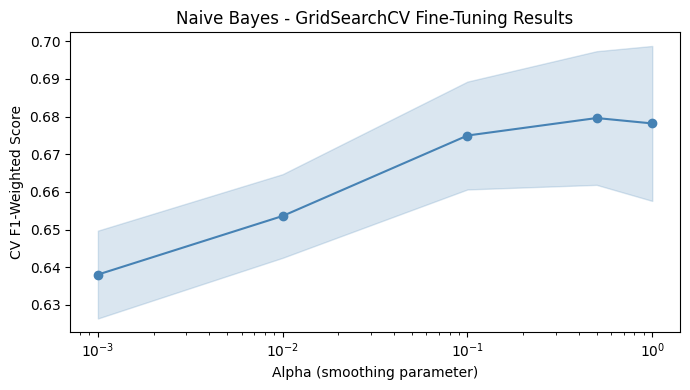

In [19]:
# Fine-tune Naive Bayes using GridSearchCV
nb_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0]
}

nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_weighted',
    n_jobs=-1
)
nb_grid.fit(X_train, y_train)

print("Best Naive Bayes alpha     :", nb_grid.best_params_['alpha'])
print("Best CV F1-weighted score  :", round(nb_grid.best_score_, 4))

nb_best = nb_grid.best_estimator_

# Plot GridSearchCV results
cv_results_nb = pd.DataFrame(nb_grid.cv_results_)
plt.figure(figsize=(7, 4))
plt.plot(nb_param_grid['alpha'], cv_results_nb['mean_test_score'], marker='o', color='steelblue')
plt.fill_between(
    nb_param_grid['alpha'],
    cv_results_nb['mean_test_score'] - cv_results_nb['std_test_score'],
    cv_results_nb['mean_test_score'] + cv_results_nb['std_test_score'],
    alpha=0.2, color='steelblue'
)
plt.xscale('log')
plt.xlabel("Alpha (smoothing parameter)")
plt.ylabel("CV F1-Weighted Score")
plt.title("Naive Bayes - GridSearchCV Fine-Tuning Results")
plt.tight_layout()
plt.show()


#### 12 - Note the results of the training process


In [20]:
# Naive Bayes training results (Requirement 12)
print("=== Naive Bayes - Training Results ===")
nb_train_pred = nb_best.predict(X_train)
print("Training Accuracy:", round(accuracy_score(y_train, nb_train_pred), 4))
print()
print(classification_report(y_train, nb_train_pred, target_names=['Negative', 'Neutral', 'Positive']))


=== Naive Bayes - Training Results ===
Training Accuracy: 0.866

              precision    recall  f1-score   support

    Negative       0.87      0.90      0.88      1400
     Neutral       0.86      0.79      0.82      1400
    Positive       0.87      0.92      0.89      1400

    accuracy                           0.87      4200
   macro avg       0.87      0.87      0.86      4200
weighted avg       0.87      0.87      0.86      4200



#### 13 - Test the model and note accuracy, precision, recall, confusion matrix, and F1


=== Naive Bayes - Test Results ===
Accuracy  : 0.6878
Precision : 0.6832
Recall    : 0.6878
F1-Score  : 0.683

              precision    recall  f1-score   support

    Negative       0.66      0.76      0.70       600
     Neutral       0.59      0.50      0.54       600
    Positive       0.80      0.81      0.80       600

    accuracy                           0.69      1800
   macro avg       0.68      0.69      0.68      1800
weighted avg       0.68      0.69      0.68      1800



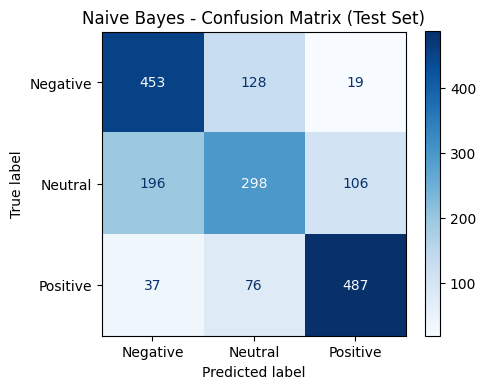

In [21]:
# Naive Bayes test results (Requirement 13)
print("=== Naive Bayes - Test Results ===")
nb_test_pred = nb_best.predict(X_test)

nb_acc = accuracy_score(y_test, nb_test_pred)
nb_pre = precision_score(y_test, nb_test_pred, average='weighted', zero_division=0)
nb_rec = recall_score(y_test, nb_test_pred, average='weighted', zero_division=0)
nb_f1  = f1_score(y_test, nb_test_pred, average='weighted', zero_division=0)

print("Accuracy  :", round(nb_acc, 4))
print("Precision :", round(nb_pre, 4))
print("Recall    :", round(nb_rec, 4))
print("F1-Score  :", round(nb_f1, 4))
print()
print(classification_report(y_test, nb_test_pred, target_names=['Negative', 'Neutral', 'Positive']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, nb_test_pred,
    display_labels=['Negative', 'Neutral', 'Positive'],
    cmap='Blues', ax=ax
)
ax.set_title("Naive Bayes - Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


### 8.2 - Model 2: MLP (Multi-Layer Perceptron)

#### 11e - Build and fine-tune the model

The sklearn MLPClassifier used here handles multi-class by default.

GridSearchCV is used to find the best hidden layer sizes, regularisation strength (alpha), and learning rate.


In [22]:
# --- 11e: Build and fine-tune the MLP model ---

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

mlp_param_grid = {
    'hidden_layer_sizes': [(16,), (32,)],
    'alpha': [0.01, 0.1, 1.0],
    'learning_rate_init': [0.001]
}

mlp_grid = GridSearchCV(
    MLPClassifier(
        max_iter=200,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=5
    ),
    mlp_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_weighted',
    n_jobs=-1
)

print("Training MLP Model with GridSearchCV...")
mlp_grid.fit(X_train, y_train_encoded)

print("Best MLP parameters       :", mlp_grid.best_params_)
print("Best CV F1-weighted score :", round(mlp_grid.best_score_, 4))

mlp_best = mlp_grid.best_estimator_

Training MLP Model with GridSearchCV...
Best MLP parameters       : {'alpha': 0.1, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001}
Best CV F1-weighted score : 0.6753


#### 12 - Note the results of the training process



=== MLP - Training Results ===
Training Accuracy: 0.8543
              precision    recall  f1-score   support

    Negative       0.90      0.84      0.87      1400
     Neutral       0.82      0.79      0.80      1400
    Positive       0.84      0.93      0.88      1400

    accuracy                           0.85      4200
   macro avg       0.86      0.85      0.85      4200
weighted avg       0.86      0.85      0.85      4200



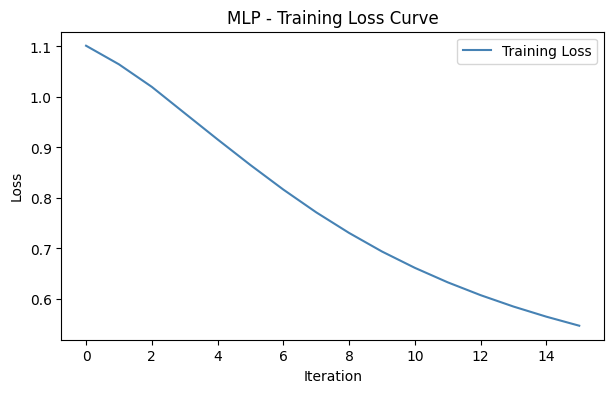

In [23]:
# ---12: Note the results of the training process ---
print("\n=== MLP - Training Results ===")
# Predict numbers, then transform back to strings for the report
mlp_train_pred_num = mlp_best.predict(X_train)
mlp_train_pred = le.inverse_transform(mlp_train_pred_num)

print("Training Accuracy:", round(accuracy_score(y_train, mlp_train_pred), 4))
print(classification_report(y_train, mlp_train_pred))

# Plot training loss
plt.figure(figsize=(7, 4))
plt.plot(mlp_best.loss_curve_, color='steelblue', label='Training Loss')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP - Training Loss Curve")
plt.legend()
plt.show()

#### 13 - Test the model and note accuracy, precision, recall, confusion matrix, and F1



=== MLP - Test Results ===
Accuracy  : 0.6883
Precision : 0.6832
Recall    : 0.6883
F1-Score  : 0.6851

Classification Report (Test Set):
              precision    recall  f1-score   support

    Negative       0.69      0.69      0.69       600
     Neutral       0.58      0.54      0.56       600
    Positive       0.78      0.84      0.81       600

    accuracy                           0.69      1800
   macro avg       0.68      0.69      0.69      1800
weighted avg       0.68      0.69      0.69      1800



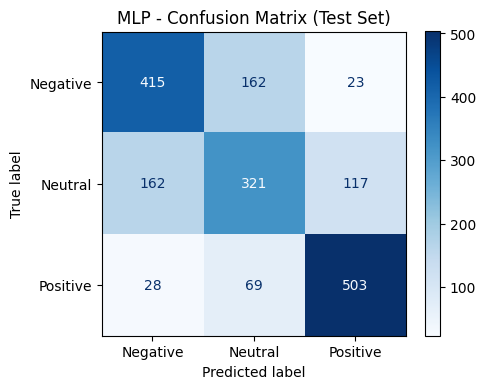

In [24]:
# --- 13: Test the model ---
print("\n=== MLP - Test Results ===")
# Predict numbers, then transform back to strings
mlp_test_pred_num = mlp_best.predict(X_test)
mlp_test_pred = le.inverse_transform(mlp_test_pred_num)

mlp_acc = accuracy_score(y_test, mlp_test_pred)
mlp_pre = precision_score(y_test, mlp_test_pred, average='weighted', zero_division=0)
mlp_rec = recall_score(y_test, mlp_test_pred, average='weighted', zero_division=0)
mlp_f1  = f1_score(y_test, mlp_test_pred, average='weighted', zero_division=0)

print("Accuracy  :", round(mlp_acc, 4))
print("Precision :", round(mlp_pre, 4))
print("Recall    :", round(mlp_rec, 4))
print("F1-Score  :", round(mlp_f1, 4))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, mlp_test_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, mlp_test_pred,
    display_labels=le.classes_,
    cmap='Blues', ax=ax
)
ax.set_title("MLP - Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

---
## Section 9 - Lexicon vs ML Models: Apples-to-Apples Comparison

### 14 - Design an experiment to compare lexicon and ML models on the same data

#### 14a - Prepare the data so both model types run on the same reviews


Step 1: Use the test-set indices saved during the 70/30 split (idx_test) to extract exactly the same 600 rows that the ML models were tested on.

Step 2: Run VADER and TextBlob on the cleaned_text of those same 600 rows.

Step 3: Compare all four models using the same ground truth labels.

This ensures we are comparing apples to apples.


In [25]:
# Step 1: Extract the test rows using the saved indices from Section 7
df_test_rows = df_test.copy()
y_true_comparison = df_test_rows['sentiment'].values


print("Test rows for comparison:", len(df_test_rows))
print("Class distribution:")
print(pd.Series(y_true_comparison).value_counts())


Test rows for comparison: 1800
Class distribution:
Negative    600
Neutral     600
Positive    600
Name: count, dtype: int64


In [26]:
# Step 2: Run VADER and TextBlob on the same test rows

analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

def textblob_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df_test_rows['vader_pred'] = df_test_rows['cleaned_text'].apply(vader_sentiment)
df_test_rows['textblob_pred'] = df_test_rows['cleaned_text'].apply(textblob_sentiment)

print("Sample of predictions on shared test rows:")
print(df_test_rows[['sentiment', 'vader_pred', 'textblob_pred']].head(5))


Sample of predictions on shared test rows:
  sentiment vader_pred textblob_pred
0  Negative    Neutral      Negative
1   Neutral   Positive      Positive
2  Negative    Neutral       Neutral
3   Neutral   Negative      Positive
4  Positive   Positive      Positive


In [27]:
# Step 3: Gather all four model predictions on the same rows
vader_preds    = df_test_rows['vader_pred'].values
textblob_preds = df_test_rows['textblob_pred'].values
nb_preds       = nb_test_pred     # from Section 8.1, same test split
mlp_preds      = mlp_test_pred    # from Section 8.2, same test split

def eval_metrics(y_true, y_pred, name):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4)
    }

comparison_df = pd.DataFrame([
    eval_metrics(y_true_comparison, vader_preds,    'VADER (Lexicon)'),
    eval_metrics(y_true_comparison, textblob_preds, 'TextBlob (Lexicon)'),
    eval_metrics(y_true_comparison, nb_preds,       'Naive Bayes (ML)'),
    eval_metrics(y_true_comparison, mlp_preds,      'MLP (ML)'),
])

print("=== All Models Compared on the Same 30% Test Set ===")
print(comparison_df.to_string(index=False))


=== All Models Compared on the Same 30% Test Set ===
             Model  Accuracy  Precision  Recall     F1
   VADER (Lexicon)    0.4483     0.4650  0.4483 0.3943
TextBlob (Lexicon)    0.4967     0.4919  0.4967 0.4733
  Naive Bayes (ML)    0.6878     0.6832  0.6878 0.6830
          MLP (ML)    0.6883     0.6832  0.6883 0.6851


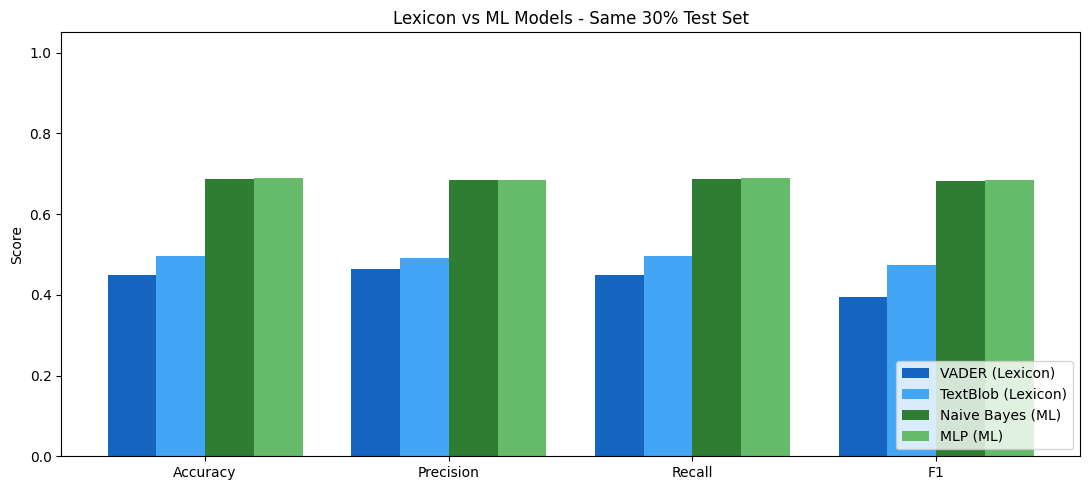

In [28]:
# Grouped bar chart comparing all four models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.2
colors = ['#1565C0', '#42A5F5', '#2E7D32', '#66BB6A']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (_, row) in enumerate(comparison_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=row['Model'], color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Lexicon vs ML Models - Same 30% Test Set")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


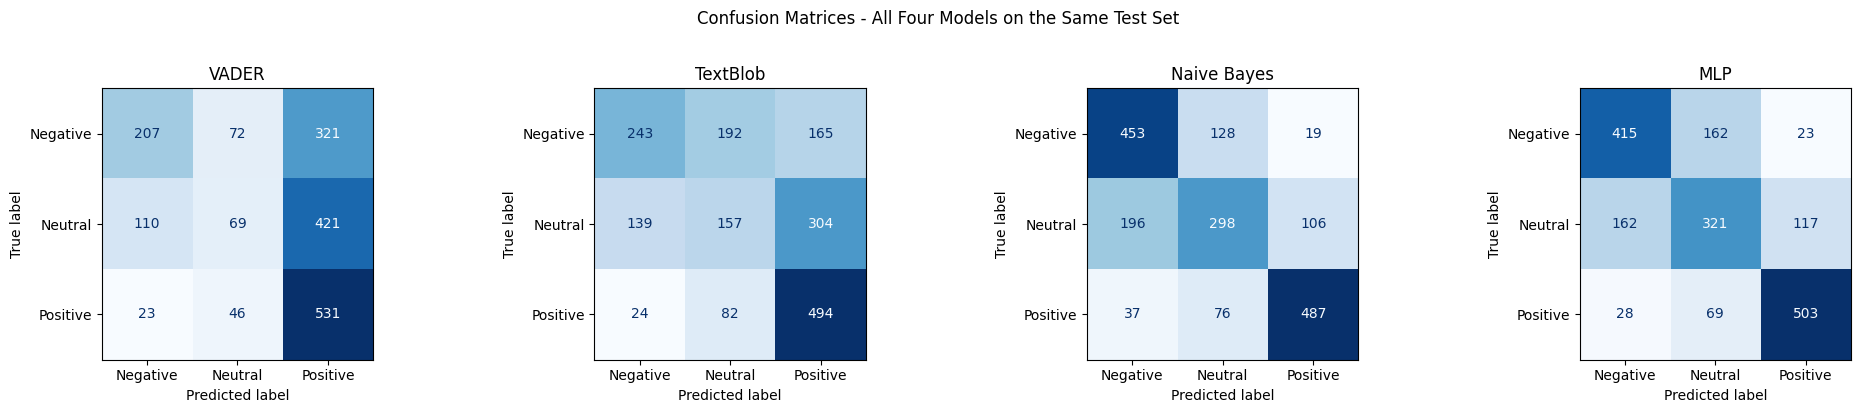

In [29]:
# Confusion matrices for all four models side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
labels = ['Negative', 'Neutral', 'Positive']
model_data = [
    ('VADER',       y_true_comparison, vader_preds),
    ('TextBlob',    y_true_comparison, textblob_preds),
    ('Naive Bayes', y_true_comparison, nb_preds),
    ('MLP',         y_true_comparison, mlp_preds)
]
for ax, (name, yt, yp) in zip(axes, model_data):
    ConfusionMatrixDisplay.from_predictions(
        yt, yp, display_labels=labels,
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name)

plt.suptitle("Confusion Matrices - All Four Models on the Same Test Set", y=1.02)
plt.tight_layout()
plt.show()


---
## Section 10 - Enhancing Rating Values Using Review Text

### 15 - Based on the recommender systems paper

#### 15a - How review text can enhance rating values


Traditional recommender systems rely on numeric star ratings alone. These ratings suffer from several limitations:

Rating sparsity: most users rate only a small number of items, leaving most user-item pairs unobserved.

Rating inconsistency: different users apply the same numeric scale differently. One user's 3-star may reflect mild satisfaction while another's reflects disappointment.

Information loss: a single integer discards all the nuanced information present in the written review.

The paper "Recommender systems based on user reviews: the state of the art" identifies sentiment-adjusted ratings as one enhancement strategy. By extracting a continuous sentiment signal from the review text and blending it with the original star rating, we can produce an enhanced rating that is more informative and more consistent across users.

#### 15b - Chosen method: Sentiment-Weighted Adjusted Rating

The method works as follows. We compute the VADER compound score from the review text, which is a continuous value between -1 and +1. We normalise both the compound score and the original star rating to the range [0, 1], then blend them using a weighted average controlled by a parameter alpha. The blended value is then rescaled back to the [1, 5] range to match the original rating scale.

Formula:

    vader_normalised  = (compound + 1) / 2         maps [-1, 1] to [0, 1]
    star_normalised   = (overall - 1) / 4           maps [1, 5] to [0, 1]
    blended_norm      = alpha * star_normalised + (1 - alpha) * vader_normalised
    enhanced_rating   = blended_norm * 4 + 1        maps [0, 1] back to [1, 5]

Alpha = 0.6 gives 60% weight to the original star rating and 40% to the text-derived sentiment.

Pseudo-code:

    For each review r in dataset:
        1. compound        = VADER_compound(r.reviewText)
        2. v_norm          = (compound + 1) / 2
        3. s_norm          = (r.overall - 1) / 4
        4. blended         = alpha * s_norm + (1 - alpha) * v_norm
        5. enhanced_rating = blended * 4 + 1
    Return dataset with new column enhanced_rating


#### 15c - Implementation


In [30]:
# Implementation: sentiment-weighted adjusted rating
ALPHA = 0.6

def compute_enhanced_rating(row, alpha=ALPHA):
    compound  = analyzer.polarity_scores(str(row['reviewText']))['compound']
    v_norm    = (compound + 1) / 2          # normalise compound score to [0, 1]
    s_norm    = (row['overall'] - 1) / 4    # normalise star rating to [0, 1]
    blended   = alpha * s_norm + (1 - alpha) * v_norm
    return round(blended * 4 + 1, 4)        # rescale back to [1, 5]

df_sample['enhanced_rating'] = df_sample.apply(compute_enhanced_rating, axis=1)

print("=== Enhanced Rating Results - First 10 Rows ===")
print(df_sample[['reviewText', 'overall', 'enhanced_rating']].head(10).to_string())


=== Enhanced Rating Results - First 10 Rows ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 reviewText  overall  enhanced_rating
0                                                                                                                                                                                                                                                                                                                                                 

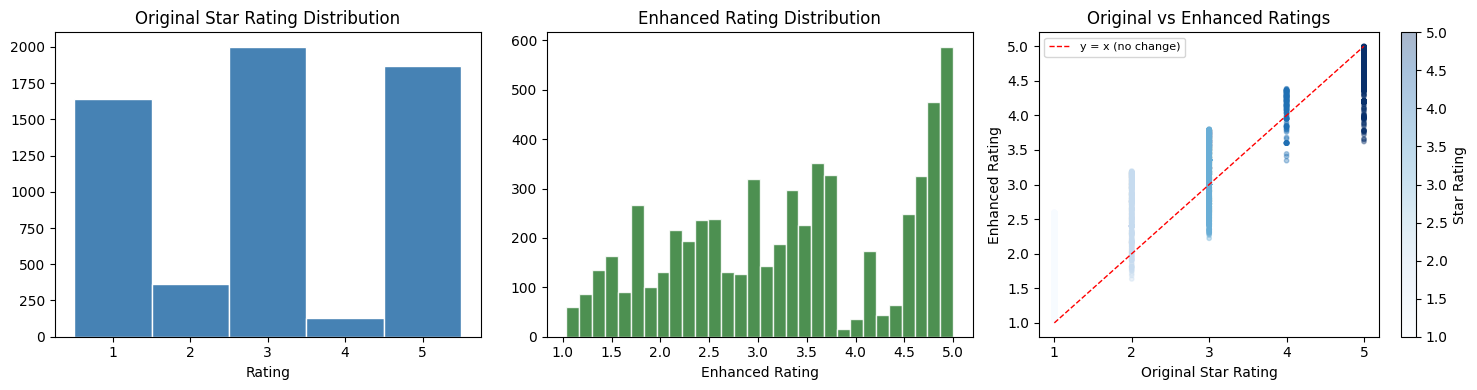

=== Statistical Comparison ===
         overall  enhanced_rating
count  6000.0000        6000.0000
mean      3.0385           3.3335
std       1.5557           1.1481
min       1.0000           1.0350
25%       1.0000           2.3958
50%       3.0000           3.3523
75%       5.0000           4.5523
max       5.0000           4.9995


In [31]:
# Visualise original vs enhanced ratings
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_sample['overall'], bins=5, range=(0.5, 5.5),
             color='steelblue', edgecolor='white')
axes[0].set_title("Original Star Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_xticks([1, 2, 3, 4, 5])

axes[1].hist(df_sample['enhanced_rating'], bins=30,
             color='#2E7D32', edgecolor='white', alpha=0.85)
axes[1].set_title("Enhanced Rating Distribution")
axes[1].set_xlabel("Enhanced Rating")

sc = axes[2].scatter(
    df_sample['overall'],
    df_sample['enhanced_rating'],
    c=df_sample['overall'], cmap='Blues',
    alpha=0.35, s=10
)
axes[2].plot([1, 5], [1, 5], 'r--', linewidth=1, label='y = x (no change)')
axes[2].set_xlabel("Original Star Rating")
axes[2].set_ylabel("Enhanced Rating")
axes[2].set_title("Original vs Enhanced Ratings")
axes[2].legend(fontsize=8)
plt.colorbar(sc, ax=axes[2], label='Star Rating')

plt.tight_layout()
plt.show()

print("=== Statistical Comparison ===")
print(df_sample[['overall', 'enhanced_rating']].describe().round(4))


In [32]:
# Identify cases where text sentiment strongly disagrees with the star rating
df_sample['rating_diff'] = abs(df_sample['enhanced_rating'] - df_sample['overall'])

high_disagreement = df_sample[df_sample['rating_diff'] > 1.5].sort_values(
    'rating_diff', ascending=False
)

print("Reviews where text sentiment strongly disagrees with the star rating:", len(high_disagreement))
print()
print(high_disagreement[['overall', 'enhanced_rating', 'rating_diff', 'reviewText']].head(5).to_string())


Reviews where text sentiment strongly disagrees with the star rating: 125

      overall  enhanced_rating  rating_diff                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

---
## Section 11 - LLM Summarisation Using a Local Hugging Face Model

### 16 - Select 10 reviews with more than 100 words and summarise to 50 words using a local LLM

We use the Qwen/Qwen2.5-0.5B-Instruct model loaded locally via the Hugging Face transformers library. This is a lightweight instruction-tuned model that can run on CPU.




In [33]:
# Select 10 reviews with more than 100 words from the subset
# Using word count on original reviewText (not cleaned_text)
df_sample['word_count'] = df_sample['reviewText'].apply(lambda t: len(str(t).split()))

long_reviews = df_sample[df_sample['word_count'] > 100].sample(
    n=10, random_state=RANDOM_STATE
).reset_index(drop=True)

print("Reviews in subset with more than 100 words:", (df_sample['word_count'] > 100).sum())
print("Selected 10 reviews, word counts:", long_reviews['word_count'].tolist())


Reviews in subset with more than 100 words: 301
Selected 10 reviews, word counts: [175, 113, 228, 203, 103, 161, 130, 110, 252, 114]


In [34]:
# Load the summarisation model locally (runs on CPU by default)
summarizer = hf_pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-0.5B-Instruct",
    device=0    # use -1 for CPU, change to 0 if a GPU is available
)
print("Summarisation model loaded successfully.")


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 5627.72it/s]


Summarisation model loaded successfully.


In [35]:
# Summarise all 10 reviews
summaries = []

for i, row in long_reviews.iterrows():
    messages = [{
        "role": "user",
        "content": (
            # Use triple quotes here to allow the multi-line prompt
            """You are an assistant. Summarise the following customer review 
            in 50 words or fewer. Return only the summary with no extra text.

            Review: """ + row['reviewText']
        )
    }]
    out = summarizer(messages, max_new_tokens=80, do_sample=False)
    
    # Note: Depending on your transformers version, you might need to check the output structure
    summary = out[0]['generated_text'][-1]['content'].strip()
    summaries.append(summary)
    
    print(f"Review {i + 1} ({row['word_count']} words):")
    print("Original:", row['reviewText'][:200], "...")
    print("Summary :", summary)
    print()

long_reviews['summary'] = summaries

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review 1 (175 words):
Original: I have never had a problem with Amazon, both when I'm ordering and selling stuff. What I do sometimes have a problem with is my own lack of thoughtfulness. Fret not, I am not going to bore you all by  ...
Summary : Amazon offers gift cards from different countries, but it's important to check the recipient's country before purchasing.



Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review 2 (113 words):
Original: I'm used to plastic gift cards that can be used to jimmy open improperly-oriented locked doors in people's homes. Since this item is made of quickly-moving positively and negatively charged electrons  ...
Summary : This plastic gift card converts easily into various forms of solid-state matter, but its mass limit seems restrictive.



Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Review 7 (130 words):
Original: I wish there was an option to select more protected, slower shipping. I would be willing to wait longer in order to receive these really cute gift boxes un-dented. I have ordered 3 different gift boxe ...
Summary : Summary: Despite being satisfied with the quick delivery time, the reviewer prefers waiting for an un-dented gift box due to its quality and value compared to other options.



Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review 8 (110 words):
Original: While this did cause a bit of a problem then I tried to use it, here is how it works.

When they mail you the card, in order to make sure someone else doesn't take and use your card they will send you ...
Summary : This product caused a minor inconvenience when mailed but worked well after being verified through phone calls.



Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review 9 (252 words):
Original: Would give this 0 stars if possible.

Bought 2 $100 gift cards. The emails were promptly delivered, but the claim links in both emails do not work. Contacted Amazon, told us to contact whole foods. We ...
Summary : Summary: Customer received 2 $100 gift cards, but emails did not work due to link issues. After contacting multiple channels, lost $400. Disappointed in poor customer support and regret for spending money. Suggests avoiding Amazon altogether.

Review 10 (114 words):
Original: The gift card arrived promptly with no hassle. It was the one I picked out and the amount I selected. However, it gave me the option to add a message. I came up with a sweet, heartfelt message that I  ...
Summary : The customer is dissatisfied with their gift card as they were expecting a message added upon receipt. They feel the message went missing after receiving the card.



In [36]:
# Report Record: First two reviews and their summaries
print("=" * 60)
print("REPORT RECORD - FIRST TWO SUMMARISED REVIEWS")
print("=" * 60)

for i in range(2):
    print()
    print("Review", i + 1)
    print("Original Text:")
    print(long_reviews.loc[i, 'reviewText'])
    print()
    print("50-Word Summary:")
    print(long_reviews.loc[i, 'summary'])
    print()


REPORT RECORD - FIRST TWO SUMMARISED REVIEWS

Review 1
Original Text:
I have never had a problem with Amazon, both when I'm ordering and selling stuff. What I do sometimes have a problem with is my own lack of thoughtfulness. Fret not, I am not going to bore you all by turning this into my own personal therapy session. But word to the wise, if you are buying an Amazon gift card for someone who lives in a foreign country, as is the case with my family member who lives in Canada, know that Amazon has sites in other countries.
  After inquiring, I'm still not sure if a card purchased at the American website can be used in a country like Canada, or any other country for that matter.
  If my gift turns out to be a dud, I'll be bummed. That's why I'm writing this, to let others know that Amazon operates in other countries, that have their own individual websites, and that hopefully, with a little awareness( which unfortunately I sometimes lack), you won't be left feeling bummed out by your C

---
## Section 12 - LLM Service Representative Response Using a Local Hugging Face Model

### 17 - Select one question-style review and generate an automated service rep response

We use the same locally hosted Qwen/Qwen2.5-0.5B-Instruct model from Section 11.



In [37]:
# Find reviews that contain a question mark and are at least 20 words
question_reviews = df_sample[
    df_sample['reviewText'].str.contains(r'\?', na=False) &
    (df_sample['word_count'] >= 20)
].copy()

print("Reviews with a question and at least 20 words:", len(question_reviews))

# Select the first qualifying review
selected_q = question_reviews.iloc[0]

print()
print("=== Selected Question Review ===")
print("Rating:", selected_q['overall'], "stars")
print("Text  :")
print(selected_q['reviewText'])


Reviews with a question and at least 20 words: 305

=== Selected Question Review ===
Rating: 3 stars
Text  :
Gift cards are difficult to order.  The amount changes to the default low amount when put in shopping list and also when put into cart.  Why does this happen?  I send these gift cards to all my children for Birthdays.  It's a pain.


In [38]:
# Generate service representative response
service_prompt = [
    {
        "role": "system",
        "content": (
            "You are a professional and empathetic customer service representative "
            "for an Amazon Gift Cards product. Respond politely, address the "
            "customer's concern directly, and offer helpful next steps."
        )
    },
    {
        "role": "user",
        "content": "Customer review: " + selected_q['reviewText']
    }
]

response_out = summarizer(service_prompt, max_new_tokens=150, do_sample=False)
service_response = response_out[0]['generated_text'][-1]['content'].strip()

print("=== Generated Service Representative Response ===")
print(service_response)


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Generated Service Representative Response ===
I'm sorry to hear that you're experiencing difficulties with ordering gift cards from Amazon. This issue can be frustrating because it affects your ability to use them effectively. Could you please provide more details about what specifically is causing the problem?

1. **Shopping List Changes**: If you have multiple items on your shopping list or add them to your cart, they might not reflect the correct total cost of those items.

2. **Cart Items**: When you place an order, the total amount may change based on the quantity selected. For example, if you select "one" item instead of "two," the total will increase by $0.99 per item.

3. **Gift Card Details**: Ensure that the gift card information (such as the amount


In [39]:
# Report Record
print("=" * 60)
print("REPORT RECORD - SERVICE REPRESENTATIVE RESPONSE")
print("=" * 60)
print()
print("Customer Review:")
print(selected_q['reviewText'])
print()
print("Generated Response:")
print(service_response)


REPORT RECORD - SERVICE REPRESENTATIVE RESPONSE

Customer Review:
Gift cards are difficult to order.  The amount changes to the default low amount when put in shopping list and also when put into cart.  Why does this happen?  I send these gift cards to all my children for Birthdays.  It's a pain.

Generated Response:
I'm sorry to hear that you're experiencing difficulties with ordering gift cards from Amazon. This issue can be frustrating because it affects your ability to use them effectively. Could you please provide more details about what specifically is causing the problem?

1. **Shopping List Changes**: If you have multiple items on your shopping list or add them to your cart, they might not reflect the correct total cost of those items.

2. **Cart Items**: When you place an order, the total amount may change based on the quantity selected. For example, if you select "one" item instead of "two," the total will increase by $0.99 per item.

3. **Gift Card Details**: Ensure that the

---
## Section 13 - Full Results Summary for Report

This section consolidates all evaluation metrics in one place for easy reference when writing the report.


In [40]:
print("=" * 60)
print("PHASE 2 - COMPLETE MODEL EVALUATION SUMMARY")
print("All models evaluated on the same 30% test split")
print("=" * 60)
print()
print(comparison_df.to_string(index=False))

print()
print("=" * 60)
print("RATING ENHANCEMENT SUMMARY")
print("=" * 60)
print(df_sample[['overall', 'enhanced_rating']].describe().round(4))

print()
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)
best_model = comparison_df.loc[comparison_df['F1'].idxmax(), 'Model']
best_f1    = comparison_df['F1'].max()
print("Best model by weighted F1 :", best_model, "(", best_f1, ")")
for _, row in comparison_df.iterrows():
    print(row['Model'], "Accuracy:", row['Accuracy'], "  F1:", row['F1'])


PHASE 2 - COMPLETE MODEL EVALUATION SUMMARY
All models evaluated on the same 30% test split

             Model  Accuracy  Precision  Recall     F1
   VADER (Lexicon)    0.4483     0.4650  0.4483 0.3943
TextBlob (Lexicon)    0.4967     0.4919  0.4967 0.4733
  Naive Bayes (ML)    0.6878     0.6832  0.6878 0.6830
          MLP (ML)    0.6883     0.6832  0.6883 0.6851

RATING ENHANCEMENT SUMMARY
         overall  enhanced_rating
count  6000.0000        6000.0000
mean      3.0385           3.3335
std       1.5557           1.1481
min       1.0000           1.0350
25%       1.0000           2.3958
50%       3.0000           3.3523
75%       5.0000           4.5523
max       5.0000           4.9995

KEY FINDINGS
Best model by weighted F1 : MLP (ML) ( 0.6851 )
VADER (Lexicon) Accuracy: 0.4483   F1: 0.3943
TextBlob (Lexicon) Accuracy: 0.4967   F1: 0.4733
Naive Bayes (ML) Accuracy: 0.6878   F1: 0.683
MLP (ML) Accuracy: 0.6883   F1: 0.6851
